File loaded successfully
Total articles: 72
        Environmental Condition  Number of Studies
0             Low-light / Night                 10
5  Adverse / Complex conditions                  2
1                    Fog / Haze                  0
2                          Rain                  0
3                         Smoke                  0
4                    Camouflage                  0


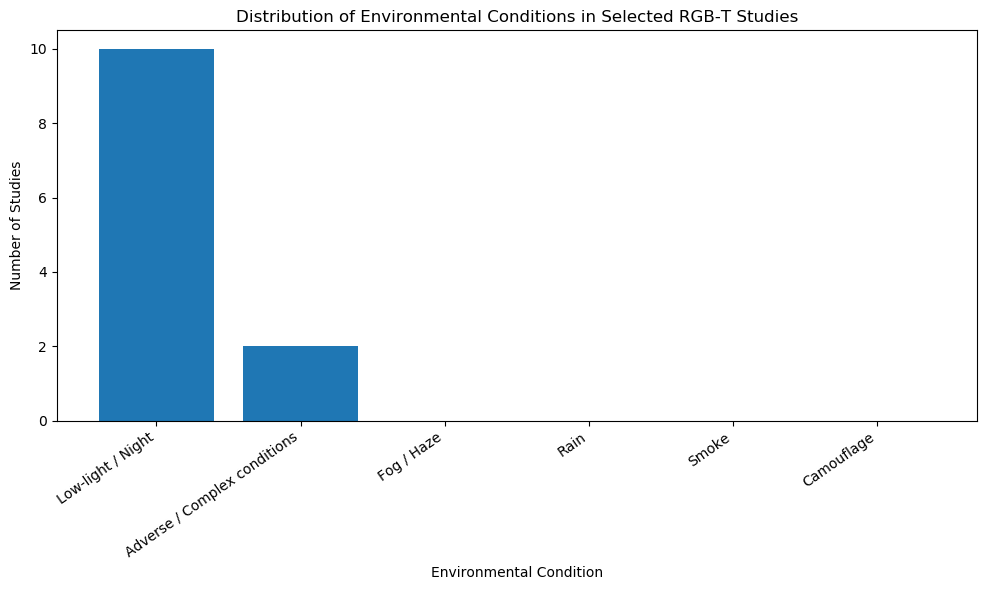

Saved: environmental_conditions_bar_chart.png
Saved: environmental_conditions_counts.xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# =========================
# 1. Load Excel file
# =========================
file_path = "C:/Users/BasilisseNiombonana/Downloads/Data/articles-retenus.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

print("File loaded successfully")
print("Total articles:", len(df))

# =========================
# 2. Combine useful text columns
# =========================
text_columns = ["Main Topic", "Title", "Abstract", "Keywords"]

existing_cols = [col for col in text_columns if col in df.columns]

df["combined_text"] = df[existing_cols].fillna("").agg(" ".join, axis=1).str.lower()

# =========================
# 3. Define environmental condition keywords
# =========================
conditions = {
    "Low-light / Night": [
        "low-light", "low light", "night", "nighttime", "dark", "illumination"
    ],
    "Fog / Haze": [
        "fog", "haze", "foggy", "hazy"
    ],
    "Rain": [
        "rain", "rainy"
    ],
    "Smoke": [
        "smoke", "smoky"
    ],
    "Camouflage": [
        "camouflage", "camouflaged"
    ],
    "Adverse / Complex conditions": [
        "adverse", "complex environment", "challenging environment",
        "bad weather", "poor visibility"
    ]
}

# =========================
# 4. Count condition occurrences
# =========================
condition_counts = {}

for condition, keywords in conditions.items():
    count = 0
    for text in df["combined_text"]:
        if any(keyword in text for keyword in keywords):
            count += 1
    condition_counts[condition] = count

condition_df = pd.DataFrame(
    list(condition_counts.items()),
    columns=["Environmental Condition", "Number of Studies"]
)

condition_df = condition_df.sort_values(
    by="Number of Studies",
    ascending=False
)

print(condition_df)

# =========================
# 5. Save results to Excel
# =========================
condition_df.to_excel("environmental_conditions_counts.xlsx", index=False)

# =========================
# 6. Generate bar chart
# =========================
plt.figure(figsize=(10, 6))
plt.bar(
    condition_df["Environmental Condition"],
    condition_df["Number of Studies"]
)

plt.xlabel("Environmental Condition")
plt.ylabel("Number of Studies")
plt.title("Distribution of Environmental Conditions in Selected RGB-T Studies")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

# Save figure for Overleaf
plt.savefig("environmental_conditions_bar_chart.png", dpi=300)
plt.show()

print("Saved: environmental_conditions_bar_chart.png")
print("Saved: environmental_conditions_counts.xlsx")